In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df  =  pd.read_csv("/content/adult_with_headers (1).csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


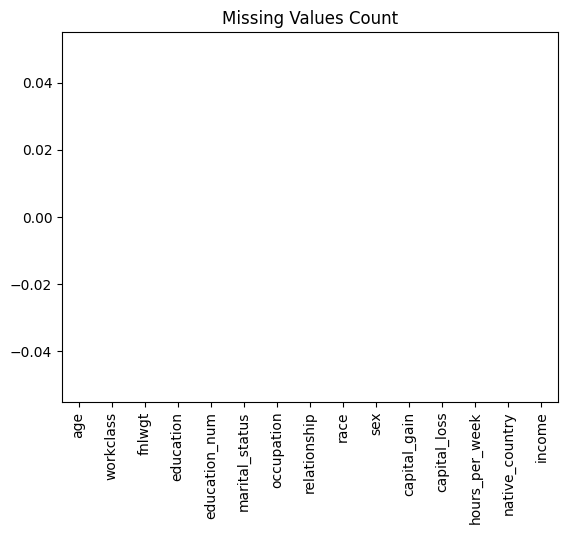

In [6]:
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values Count")
plt.show()   # no missing values are present in the dataset

#feature scaling

In [7]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler

In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_std = df.copy()
df_mm = df.copy()

df_std[num_cols] = std_scaler.fit_transform(df[num_cols])
df_mm[num_cols] = minmax_scaler.fit_transform(df[num_cols])


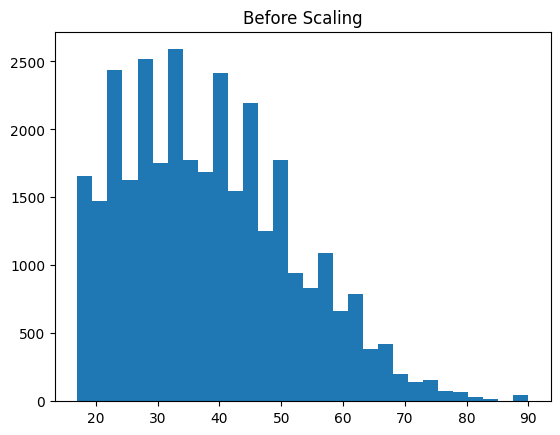

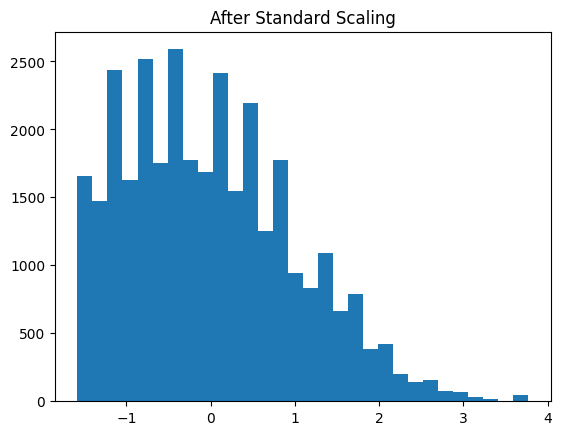

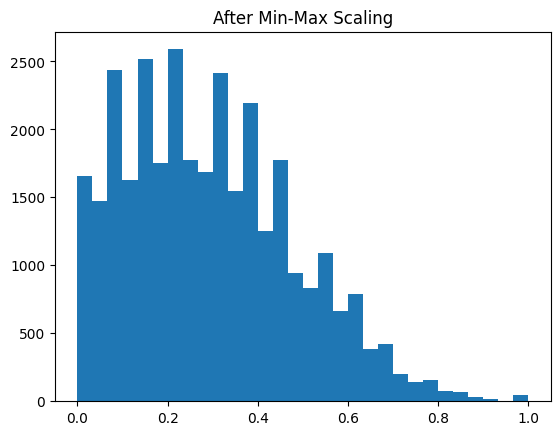

In [9]:
plt.hist(df[num_cols[0]], bins=30)
plt.title("Before Scaling")
plt.show()

plt.hist(df_std[num_cols[0]], bins=30)
plt.title("After Standard Scaling")
plt.show()

plt.hist(df_mm[num_cols[0]], bins=30)
plt.title("After Min-Max Scaling")
plt.show()


In [10]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols].nunique()

,0
workclass,9
education,16
marital_status,7
occupation,15
relationship,6
race,5
sex,2
native_country,42
income,2


In [11]:
small_cat = [col for col in cat_cols if df[col].nunique() < 5]

df = pd.get_dummies(df, columns=small_cat, drop_first=True)

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
large_cat = [col for col in cat_cols if col not in small_cat]

for col in large_cat:
    df[col] = le.fit_transform(df[col])


In [13]:
df['capital_net'] = df['capital_gain'] - df['capital_loss']
df['hours_per_day'] = df['hours_per_week'] / 7

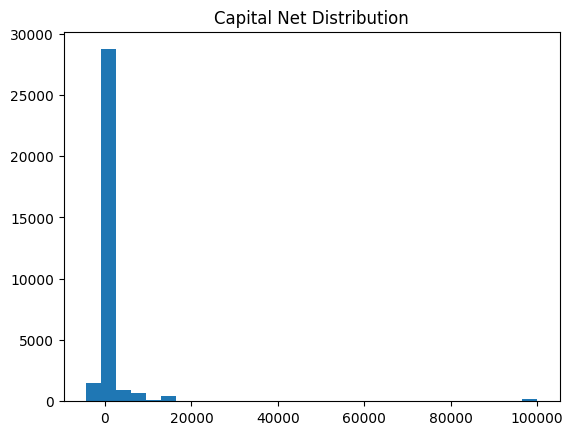

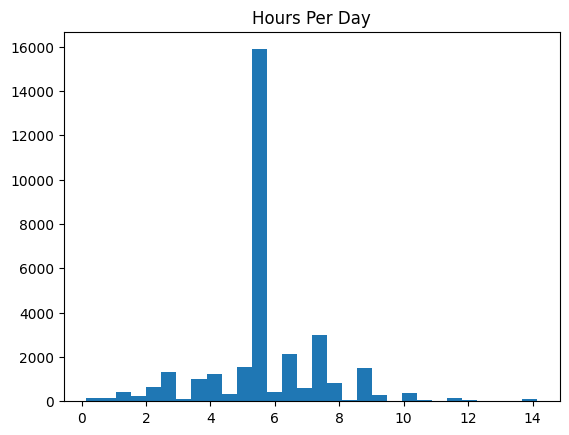

In [14]:
plt.hist(df['capital_net'], bins=30)
plt.title("Capital Net Distribution")
plt.show()

plt.hist(df['hours_per_day'], bins=30)
plt.title("Hours Per Day")
plt.show()


In [15]:
df['capital_gain'].skew()

np.float64(11.953847687699799)

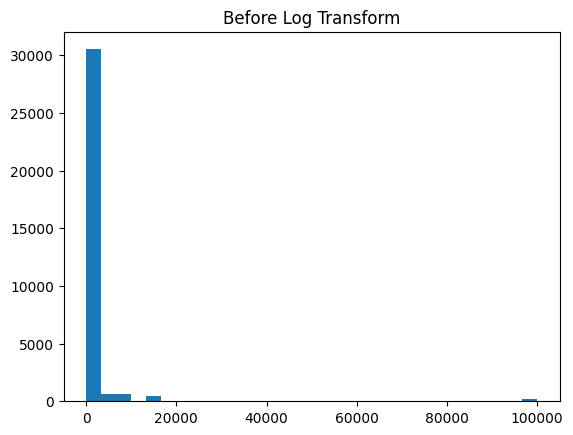

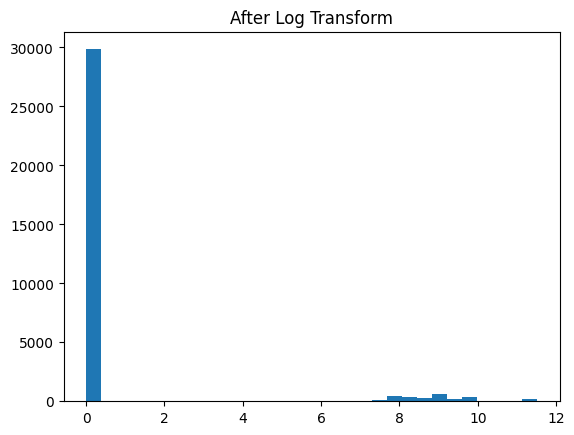

In [16]:
df['log_capital_gain'] = np.log1p(df['capital_gain'])

plt.hist(df['capital_gain'], bins=30)
plt.title("Before Log Transform")
plt.show()

plt.hist(df['log_capital_gain'], bins=30)
plt.title("After Log Transform")
plt.show()


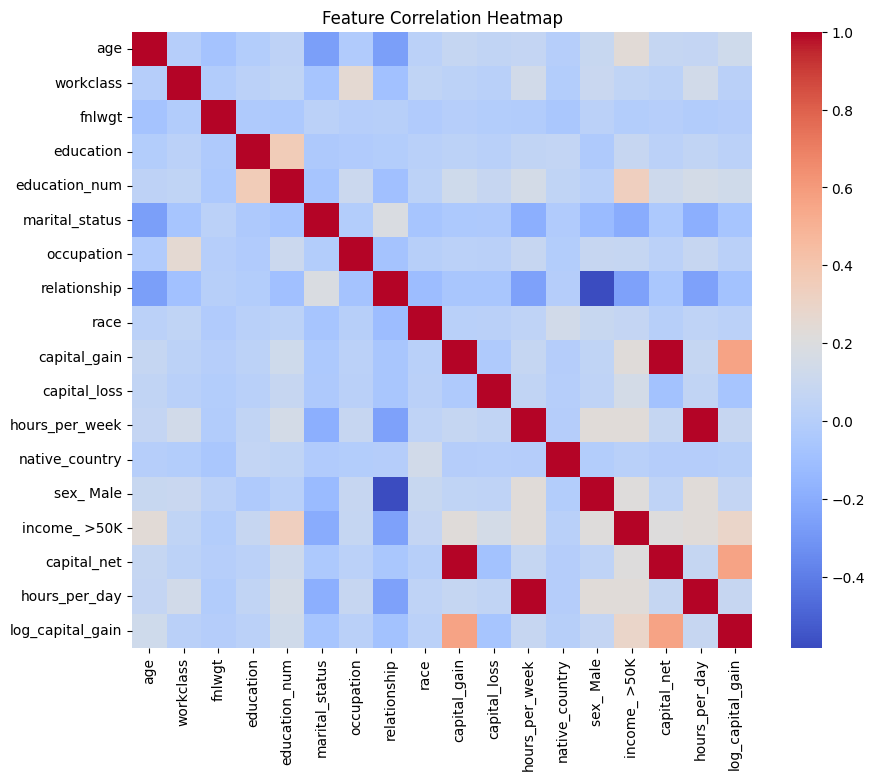

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
